# **1. Entendimiento del problema**

El gobierno australiano quiere concoer cuánto puede ser el costo del uso de corticoides y esteroides en el sistema de salud actual para preparar sus finanzas a futuro

# **2. Enfoque analítico**

Construir un modelo de regresión basado en series de tiempo que permiten estimar el costo de los corticoides y esteroides con el menor MAE posible

# **3. Requerimiento de datos**

Se requieren los datos pasados del costo de los medicamentos

# **4. Recolección de datos**

In [1]:
import matplotlib.pyplot as plt
from skforecast.datasets import fetch_dataset

In [3]:
data = fetch_dataset('h2o_exog')
data.index.name = 'datetime'

╭─────────────────────────────────── h2o_exog ────────────────────────────────────╮
│ Description:                                                                    │
│ Monthly expenditure ($AUD) on corticosteroid drugs that the Australian health   │
│ system had between 1991 and 2008. Two additional variables (exog_1, exog_2) are │
│ simulated.                                                                      │
│                                                                                 │
│ Source:                                                                         │
│ Hyndman R (2023). fpp3: Data for Forecasting: Principles and Practice (3rd      │
│ Edition). http://pkg.robjhyndman.com/fpp3package/,                              │
│ https://github.com/robjhyndman/fpp3package, http://OTexts.com/fpp3.             │
│                                                                                 │
│ URL:                                                                            │
│ https://raw.githubusercontent.com/skforecast/skforecast-                        │
│ datasets/main/data/h2o_exog.csv                                                 │
│                                                                                 │
│ Shape: 195 rows x 3 columns                                                     │
╰─────────────────────────────────────────────────────────────────────────────────╯

In [4]:
data

,y,exog_1,exog_2
datetime,,,
1992-04-01,0.379808,0.958792,1.166029
1992-05-01,0.361801,0.951993,1.117859
1992-06-01,0.410534,0.952955,1.067942
1992-07-01,0.483389,0.958078,1.097376
1992-08-01,0.475463,0.956370,1.122199
...,...,...,...
2008-02-01,0.761822,1.515840,1.786373
2008-03-01,0.649435,1.506258,1.694264
2008-04-01,0.827887,1.505253,1.627135


# **5. Exploración de Datos**

- Identificar los patrones estacionales de la serie
- Determinar la estacionariedad de la serie

In [5]:
from skforecast.plot import set_dark_theme
set_dark_theme()

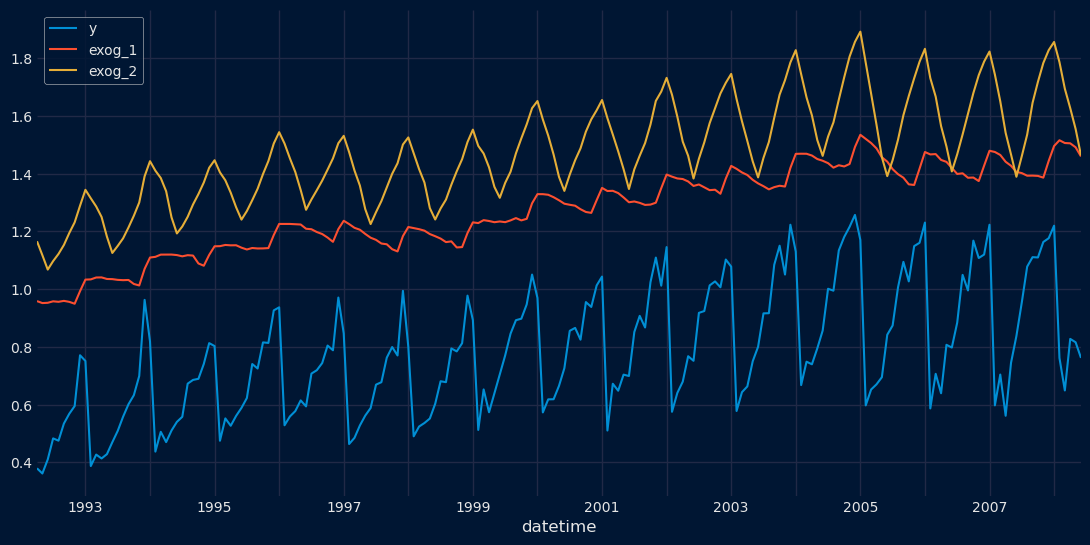

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
data.plot(ax=ax)
ax.legend()
plt.show()

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

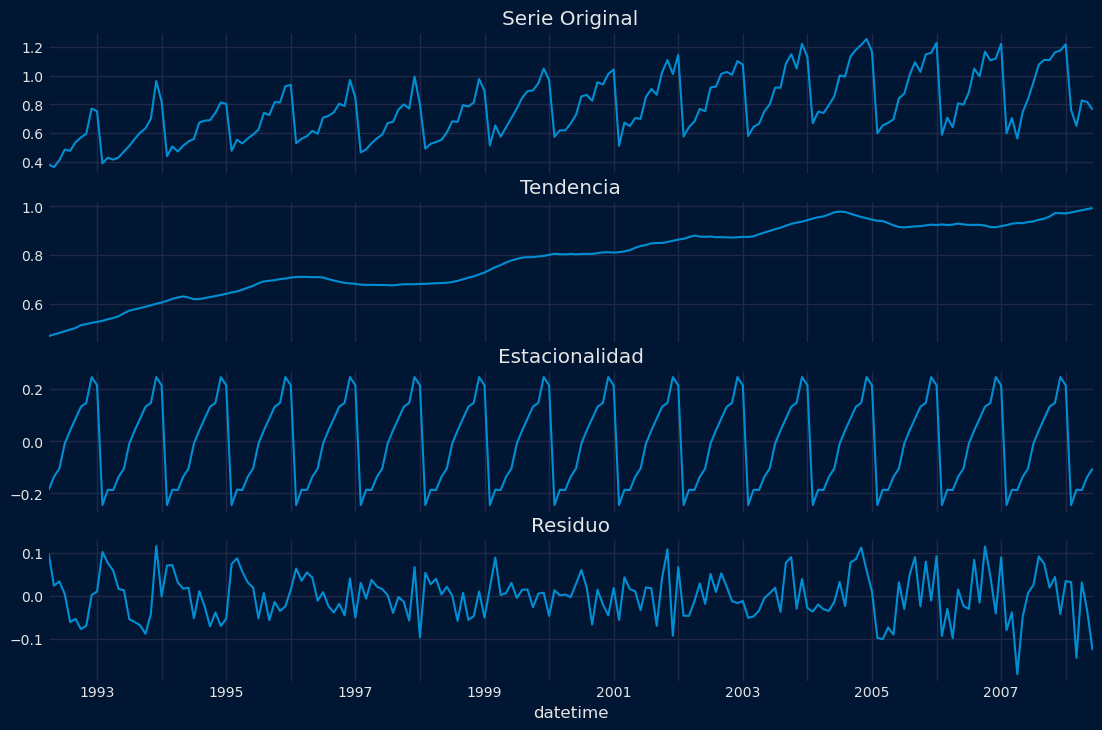

In [13]:
res_decompose = seasonal_decompose(data['y'], model='additive', extrapolate_trend='freq') # additive o multiplicative
fig, ax = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
res_decompose.observed.plot(ax=ax[0])
ax[0].set_title('Serie Original')
res_decompose.trend.plot(ax=ax[1])
ax[1].set_title('Tendencia')
res_decompose.seasonal.plot(ax=ax[2])
ax[2].set_title('Estacionalidad')
res_decompose.resid.plot(ax=ax[3])
ax[3].set_title('Residuo')
plt.show()

**Análisis**

- M: 12 (Cada 12 periodos se repite el elemento de Componente Estacional)
- Residuo: ruido blanco

In [14]:
from statsmodels.tsa.stattools import adfuller

In [16]:
print('Test Estacionariedad de Dickey-Fuller Aumentado')
result = adfuller(data['y'])
print('ADF Estadístico:', result[0])
print('Valor p:', result[1])
print('Número de lags utilizados:', result[2])
print('Número de observaciones utilizadas para la regresión:', result[3])
print('Valores críticos:')
for key, value in result[4].items():
    print(f'   {key}: {value}')

Test Estacionariedad de Dickey-Fuller Aumentado
ADF Estadístico: -1.518045806093359
Valor p: 0.5245662008648596
Número de lags utilizados: 15
Número de observaciones utilizadas para la regresión: 179
Valores críticos:
   1%: -3.4674201432469816
   5%: -2.877826051844538
   10%: -2.575452082332012


SE RECHAZA

# **6. Preparación de los Datos**

- Diferenciar la serie
- Identificar su comportamiento estacional

Test Estacionariedad de Dickey-Fuller Aumentado
ADF Estadístico: -3.2725011930230257
Valor p: 0.016153320135670685


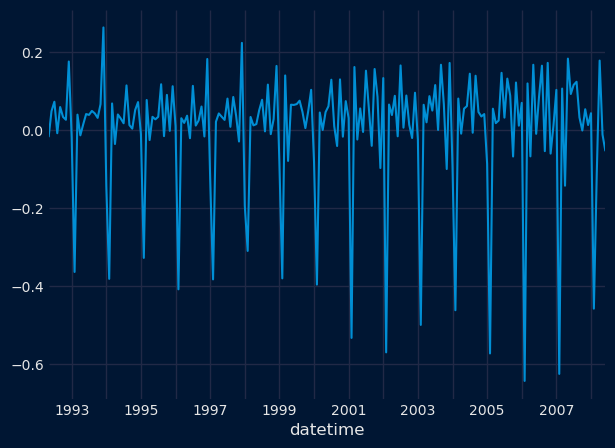

In [17]:
data_diff = data['y'].diff().dropna()
print('Test Estacionariedad de Dickey-Fuller Aumentado')
result = adfuller(data_diff)
print('ADF Estadístico:', result[0])
print('Valor p:', result[1])
data_diff.plot()
plt.show()

In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

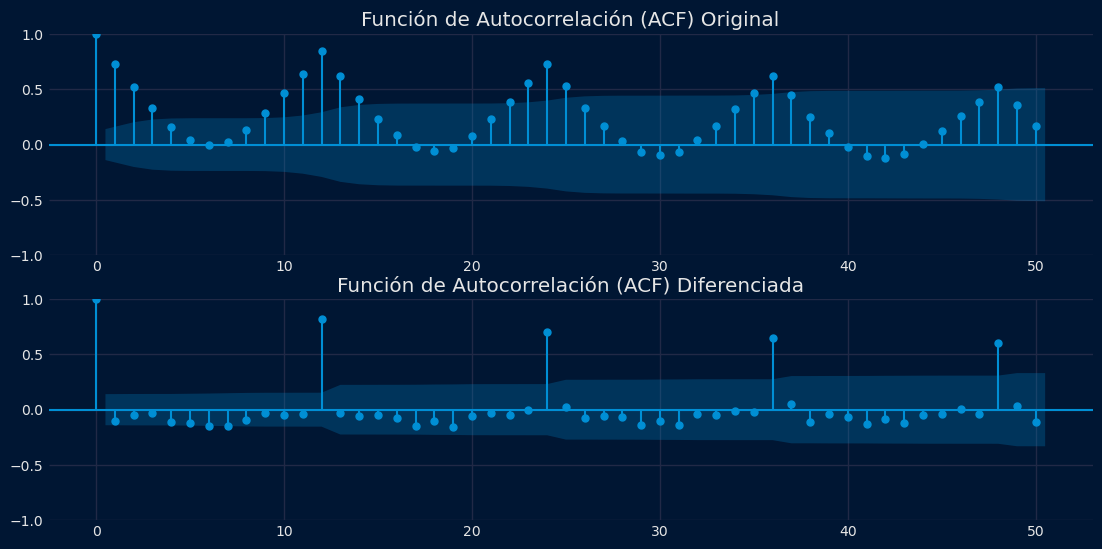

In [21]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6))
plot_acf(data['y'], lags=50, ax=ax[0], alpha=0.05)
ax[0].set_title('Función de Autocorrelación (ACF) Original')
plot_acf(data_diff, lags=50, ax=ax[1], alpha=0.05)
ax[1].set_title('Función de Autocorrelación (ACF) Diferenciada')
plt.show()

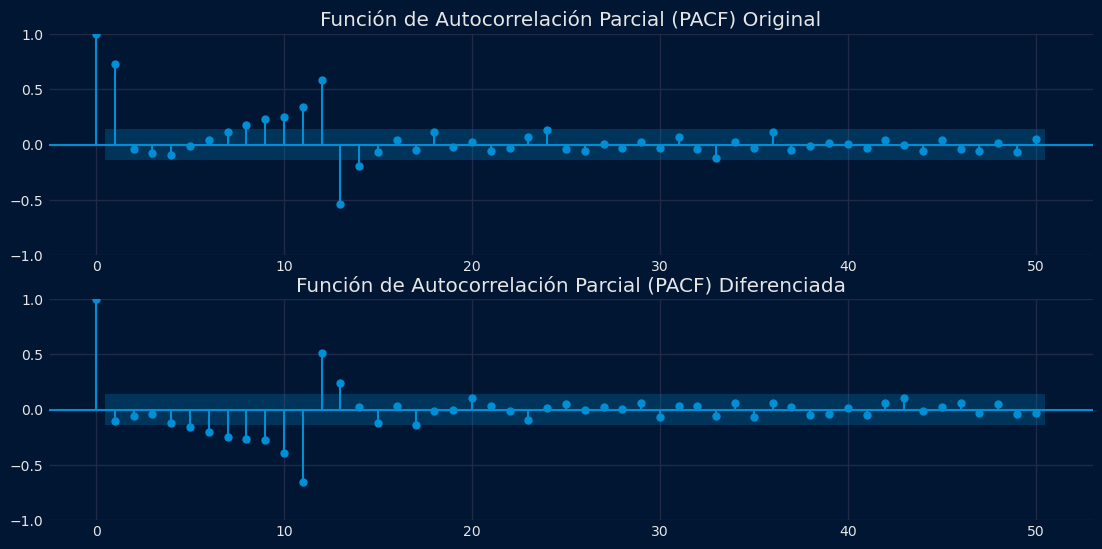

In [22]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6))
plot_pacf(data['y'], lags=50, ax=ax[0], alpha=0.05)
ax[0].set_title('Función de Autocorrelación Parcial (PACF) Original')
plot_pacf(data_diff, lags=50, ax=ax[1], alpha=0.05)
ax[1].set_title('Función de Autocorrelación Parcial (PACF) Diferenciada')
plt.show()